In [169]:
%matplotlib inline
import re
import sys
import os
import json
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from underthesea import word_tokenize

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from src.storage.db import get_connection

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [170]:
conn = get_connection()
df_raw = pd.read_sql('SELECT * FROM articles', conn)

def fix_text(x):
    if not isinstance(x, str):
        return x
    try:
        return x.encode('latin1').decode('utf-8')
    except:
        return x

for col in ['title', 'content', 'url']:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(fix_text)

print(f'Total rows loaded: {len(df_raw):,}')
df_raw.head(3)

Total rows loaded: 512


,id,source,title,url,image,published_at,crawled_at,content
0,987,vnexpress,"Tim Cook rời vị trí CEO Apple, chuyển giao cho...",https://vnexpress.net/tim-cook-roi-vi-tri-ceo-...,https://i1-vnexpress.vnecdn.net/2026/04/21/app...,2026-04-20 22:35:16+00:00,2026-04-21 01:25:02.164922+00:00,"Ngày 20/4, hãng cho biết quyết định đã được Hộ..."
1,1,vnexpress,"'Chậm một nhịp công nghệ, Việt Nam có thể lỡ c...",https://vnexpress.net/cham-mot-nhip-cong-nghe-...,https://i1-vnexpress.vnecdn.net/2026/04/20/202...,2026-04-20 09:34:24+00:00,2026-04-20 11:53:50.457832+00:00,"Tại phiên thảo luận hội trường chiều 20/4, đại..."
2,990,vnexpress,Phi hành đoàn Artemis II và trạm Thiên Cung lậ...,https://vnexpress.net/phi-hanh-doan-artemis-ii...,https://i1-vnexpress.vnecdn.net/2026/04/20/kuj...,2026-04-20 09:10:41+00:00,2026-04-21 01:25:02.164922+00:00,"Theo tính toán của Jonathan McDowell, nhà thiê..."


In [171]:
df_raw.info()
df_raw.isnull().sum().rename('missing').to_frame()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 512 entries, 0 to 511
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   id            512 non-null    int64              
 1   source        512 non-null    object             
 2   title         512 non-null    object             
 3   url           512 non-null    object             
 4   image         218 non-null    object             
 5   published_at  512 non-null    datetime64[ns, UTC]
 6   crawled_at    512 non-null    datetime64[ns, UTC]
 7   content       500 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(1), object(5)
memory usage: 32.1+ KB


,missing
id,0
source,0
title,0
url,0
image,294
published_at,0
crawled_at,0
content,12


In [172]:
df = df_raw.copy()
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)

cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=7)
df = df[df['published_at'] >= cutoff].reset_index(drop=True)

df['content'] = df['content'].fillna('')
df['title']   = df['title'].fillna('')
df['url']     = df['url'].fillna('') if 'url' in df.columns else ''

df = df.drop_duplicates(subset=['url']).reset_index(drop=True)
df = df.drop_duplicates(subset=['title']).reset_index(drop=True)

print(f'Articles in past 7 days (after dedup): {len(df):,}')
print(f'Date range: {df["published_at"].min().date()} -> {df["published_at"].max().date()}')

Articles in past 7 days (after dedup): 194
Date range: 2026-04-14 -> 2026-04-21


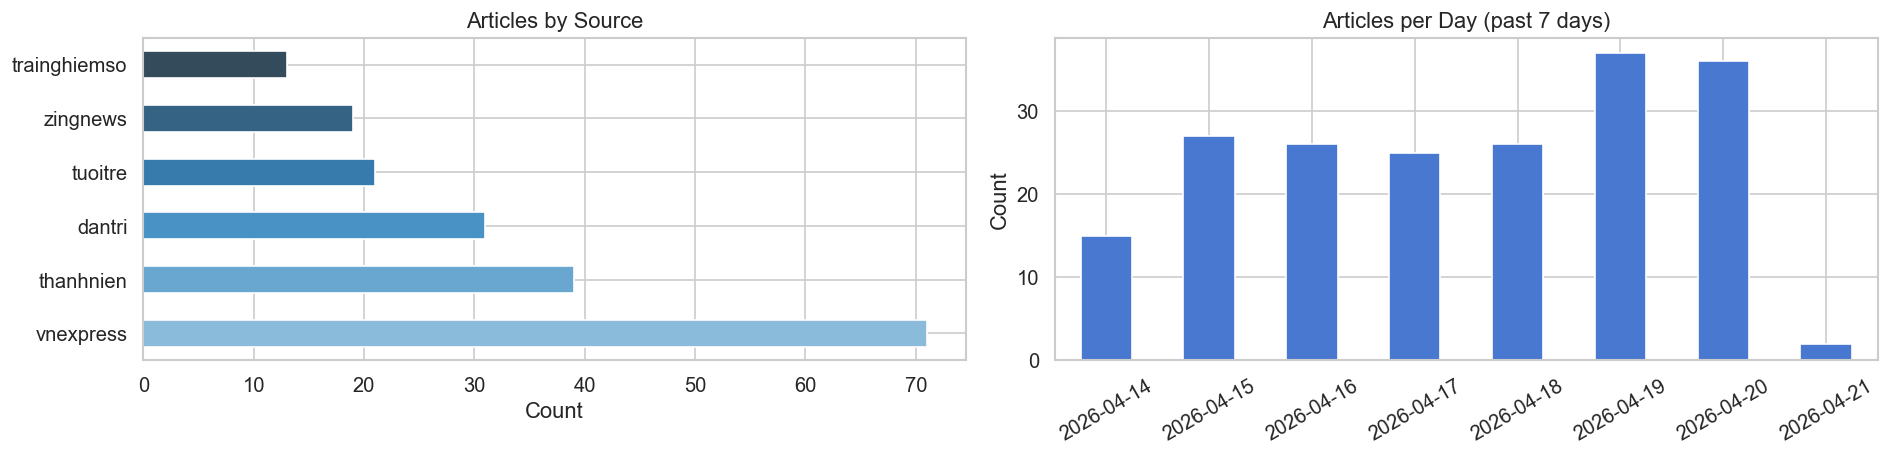

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

source_counts = df['source'].value_counts()
source_counts.plot(
    kind='barh', ax=axes[0],
    color=sns.color_palette('Blues_d', len(source_counts))
)
axes[0].set_title('Articles by Source')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

daily = df.groupby(df['published_at'].dt.date).size()
daily.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[0])
axes[1].set_title('Articles per Day (past 7 days)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [174]:
IMPORTANT_ENGLISH_KEYWORDS = {
    'ai', 'ml', 'llm', 'gpt', 'openai', 'chatgpt', 'github', 'python', 'java',
    'javascript', 'typescript', 'sql', 'api', 'web', 'app', 'ios', 'android',
    'cloud', 'aws', 'azure', 'google', 'meta', 'nvidia', 'tesla', 'apple',
    'samsung', 'iphone', 'bitcoin', 'ethereum', 'blockchain', 'nft', 'metaverse',
    'vr', 'ar', 'iot', 'ota', 'crm', 'erp', 'saas', 'paas', 'iaas', 'edge',
    'quantum', 'chip', '5g', '6g', 'cpu', 'gpu', 'ram', 'ssd', 'usb',
    'wifi', 'bluetooth', 'hdmi', 'usb-c', 'oled', 'amoled',
    'battery', 'megapixel', 'fps', 'tps', 'latency', 'bandwidth',
    'vpn', 'proxy', 'firewall', 'encryption', 'hash', 'zero-day',
    'exploit', 'malware', 'ransomware', 'trojan', 'worm', 'bot', 'ddos',
}

STOPWORDS = {
    'một_số','tuy_nhiên','đồng_thời','không_chỉ','thay_vì',
    'trong_khi','bên_cạnh','ngoài_ra','theo_đó','do_đó',
    'vì_vậy','mặc_dù','bởi_vì','chẳng_hạn','hay_là',
    'hơn','sao','tàu','kỳ','tận','ưu','tiên','nhân','ích',
    'gói','bộ','kho','nút','cúp','trẻ','già','gia','chủ',
    'thừa','khuyên','bắt','ép','mách','báo','kể','nói',
    'có_thể','sử_dụng','cho_phép','giúp_đỡ','thực_hiện',
    'xây_dựng','hoạt_động','tiếp_tục','bao_gồm','liên_quan',
    'tham_gia','chia_sẻ','thành_công','hiệu_quả','quan_trọng',
    'trong','của','với','tại','từ','theo','qua','bằng',
    'hay','còn','mà','nếu','khi','vì','để','là','và',
    'ra','vào','đến','lại','đã','sẽ','đang','được','bị',
    'một','những','nhiều','này','đây','các','cùng','đó',
    'như','sau','trên','cho','cần','có','không','làm',
    'người','người_dùng','sản_phẩm','dịch_vụ','công_ty',
    'hệ_thống','phát_triển','thiết_bị','tính_năng','khả_năng',
    'thông_tin','nội_dung','vấn_đề','trường_hợp','thời_gian',
    'việc','điều','cách','loại','số','mức','lần','công_nghệ',
    'năm','tháng','ngày','tuần','giờ',
    'http','https','www','com','vn','html','utm','org','net',
    'họ','ta','tôi','bạn','chúng','mình','anh','chị',
    'tp','hcm',
    'được','đang','sẽ','đã','phải','cần',
    'dùng','làm','tạo','cho','giúp','trợ','thực','thấy',
    'hoặc','và','nhưng','nếu','vì','nên',
    'mới','cũ','lớn','nhỏ','tốt','xấu','nhanh',
    'dân_trí','vnexpress','thanh_niên','tuổi_trẻ','báo_chí',
    'trang_web','website','công_bố','thông_báo','tin_tức',
}

MOJIBAKE_TERMS = ['thá', 'á_ng', 'á_c', 'cã³', 'thã', 'láñ', 'lá¡', 'ã¡', 'ã©', 'ã³', 'ãº']

def clean_text(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(tokenized_text):
    tokens = tokenized_text.split()
    filtered = []
    for t in tokens:
        is_english = t.isascii() and t.isalpha()
        is_important_english = t.lower() in IMPORTANT_ENGLISH_KEYWORDS
        if is_important_english:
            filtered.append(t)
        elif (
            t not in STOPWORDS
            and len(t) > 2
            and not t.isnumeric()
            and not is_english
        ):
            filtered.append(t)
    return ' '.join(filtered)

df['text_raw'] = (df['title'] + ' ' + df['content']).str.lower()
df['text_clean'] = df['text_raw'].apply(clean_text)
df['mojibake_count'] = df['text_clean'].apply(lambda x: sum(x.count(t) for t in MOJIBAKE_TERMS))
df['tokenized'] = df['text_clean'].apply(lambda x: word_tokenize(x, format='text'))
df['tokenized'] = df['tokenized'].apply(remove_stopwords)

df = df[df['mojibake_count'] < 2].drop('mojibake_count', axis=1).reset_index(drop=True)

MIN_TOKEN_LEN = 20
df = df[df['tokenized'].str.split().str.len() >= MIN_TOKEN_LEN].reset_index(drop=True)

print(f'Articles after mojibake + min-token filter: {len(df):,}')
print(df['tokenized'].str.split().str.len().describe())

Articles after mojibake + min-token filter: 94
count     94.000000
mean     172.829787
std      109.923203
min       20.000000
25%      116.750000
50%      169.500000
75%      231.250000
max      653.000000
Name: tokenized, dtype: float64


In [175]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(2, 2),
    stop_words=list(STOPWORDS),
    token_pattern=r'(?u)\b\w\w+\b',
    min_df=2,
)
tfidf_matrix = tfidf.fit_transform(df['tokenized'])
tfidf_scores = dict(zip(
    tfidf.get_feature_names_out(),
    tfidf_matrix.mean(axis=0).A1
))

top50_df = pd.DataFrame(
    sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:50],
    columns=['keyword', 'tfidf_score']
)
print('Top 50 TF-IDF keywords (raw, pre-semantic filter):')
top50_df.head(50)

Top 50 TF-IDF keywords (raw, pre-semantic filter):


,keyword,tfidf_score
0,thuê di_động,0.038884
1,ảnh chụp,0.035440
2,xác_thực thuê,0.031529
3,chụp màn_hình,0.031196
4,mạng xã_hội,0.026902
5,trí_tuệ nhân_tạo,0.025236
6,bản cập_nhật,0.024767
7,bên cạnh,0.023408
8,bên thứ,0.022434
9,bài viết,0.020166


In [176]:
MODEL_NAME = 'keepitreal/vietnamese-sbert'
sbert = SentenceTransformer(MODEL_NAME)
print(f'Model loaded: {MODEL_NAME}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18191.59it/s]
RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: keepitreal/vietnamese-sbert


In [177]:
TECH_QUERIES = [
    'trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini',
    'điện thoại smartphone iphone samsung chip vi xử lý màn hình camera',
    'phần mềm ứng dụng lập trình code backend frontend framework',
    'an ninh mạng bảo mật dữ liệu hacker tấn công mã hóa',
    'xe điện năng lượng pin sạc xe tự lái ô tô điện',
    'mạng xã hội facebook tiktok youtube instagram người dùng nội dung',
    'khởi nghiệp startup đầu tư gọi vốn định giá IPO',
    'máy tính laptop desktop server chip CPU GPU',
    'blockchain bitcoin ethereum tiền mã hóa crypto',
]

texts_for_embed = (df['title'] + '. ' + df['content'].str[:512]).tolist()
article_embeddings = sbert.encode(
    texts_for_embed, batch_size=64, show_progress_bar=True, normalize_embeddings=True
)
query_embeddings = sbert.encode(TECH_QUERIES, normalize_embeddings=True)

sim_matrix = cosine_similarity(article_embeddings, query_embeddings)

df['tech_score'] = sim_matrix.max(axis=1)
df['tech_topic_idx'] = sim_matrix.argmax(axis=1)
df['tech_topic'] = [TECH_QUERIES[i] for i in df['tech_topic_idx']]

print(df[['title', 'source', 'tech_score', 'tech_topic']].sort_values('tech_score', ascending=False).head(10).to_string())
print(f"\nScore range: {df['tech_score'].min():.3f} - {df['tech_score'].max():.3f}")
print(f"Score percentiles:")
print(df['tech_score'].quantile([.25, .5, .75, .9, .95]).to_string())

Batches: 100%|██████████| 2/2 [00:10<00:00,  5.25s/it]


                                                                                title     source  tech_score                                                                        tech_topic
84        Google triển khai tính năng trí thông minh cá nhân trên Gemini tại Việt Nam     dantri    0.534944  trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini
6                                    Xây dựng kho dữ liệu ngành Khoa học và Công nghệ  vnexpress    0.533092                       phần mềm ứng dụng lập trình code backend frontend framework
50                             Lý do Chrome khiến SSD nhanh hao mòn và cách khắc phục  thanhnien    0.493375                       phần mềm ứng dụng lập trình code backend frontend framework
23                                      Thử nghiệm đưa 100.000 USD cho AI mở cửa hàng  vnexpress    0.490137  trí tuệ nhân tạo AI machine learning deep learning mô hình chatgpt openai gemini
26                              Thay đổi nhỏ 

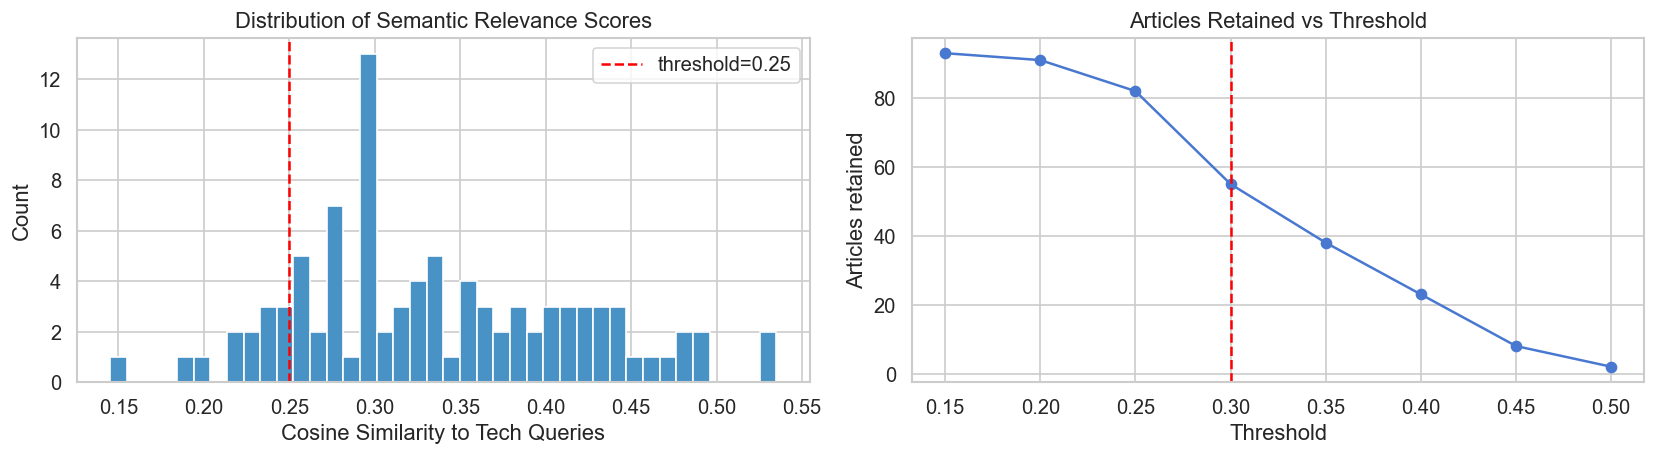

 threshold  n_articles
      0.15          93
      0.20          91
      0.25          82
      0.30          55
      0.35          38
      0.40          23
      0.45           8
      0.50           2

Selected threshold: 0.25  ->  82 / 94 articles


In [178]:
thresholds = np.arange(0.15, 0.55, 0.05)
coverage = [(t, (df['tech_score'] >= t).sum()) for t in thresholds]
cov_df = pd.DataFrame(coverage, columns=['threshold', 'n_articles'])

THRESHOLD = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['tech_score'], bins=40, color=sns.color_palette('Blues_d')[2], edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label='threshold={:.2f}'.format(THRESHOLD))
axes[0].set_title('Distribution of Semantic Relevance Scores')
axes[0].set_xlabel('Cosine Similarity to Tech Queries')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].plot(cov_df['threshold'], cov_df['n_articles'], marker='o', color=sns.color_palette('muted')[0])
axes[1].axvline(0.30, color='red', linestyle='--')
axes[1].set_title('Articles Retained vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Articles retained')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(cov_df.to_string(index=False))

df_tech = df[df['tech_score'] >= THRESHOLD].reset_index(drop=True)
print(f'\nSelected threshold: {THRESHOLD}  ->  {len(df_tech):,} / {len(df):,} articles')

In [179]:
tech_idx = df[df['tech_score'] >= THRESHOLD].index.tolist()
tech_embeddings = article_embeddings[tech_idx]

n_tech = len(tech_idx)
if n_tech < 8:
    raise ValueError(f"Not enough tech articles after filtering: {n_tech}. Lower THRESHOLD or collect more data.")

pca_pre = PCA(n_components=min(30, n_tech - 1), random_state=42)
emb_reduced = pca_pre.fit_transform(tech_embeddings)
print(f'Variance explained by 30 PCs: {pca_pre.explained_variance_ratio_.sum():.1%}')

def get_cluster_labels_dict(embeddings, tokenized_series, labels, stopwords, sbert_model, top_n=5):
    result = {}
    for c in sorted(set(labels)):
        mask = labels == c
        subset = tokenized_series[mask]
        c_embeds = embeddings[mask]
        if len(subset) == 0:
            result[c] = 'empty'
            continue
        vec = TfidfVectorizer(max_features=200, stop_words=list(stopwords),
                              ngram_range=(1, 2), min_df=1,
                              token_pattern=r'(?u)\b\w\w+\b')
        mat = vec.fit_transform(subset)
        kw_scores = dict(zip(vec.get_feature_names_out(), mat.mean(axis=0).A1))
        kw_list = list(kw_scores.keys())
        kw_embeds = sbert_model.encode(kw_list, normalize_embeddings=True, show_progress_bar=False)
        center = normalize(c_embeds.mean(axis=0, keepdims=True))
        sem = cosine_similarity(kw_embeds, center).flatten()
        combined = {kw: kw_scores[kw] * sem[i] for i, kw in enumerate(kw_list)}
        top = sorted(combined, key=combined.get, reverse=True)[:top_n]
        result[c] = ' | '.join(top)
    return result

def topic_coherence(tokenized_series, labels, top_n=10):
    scores = []
    for c in sorted(set(labels)):
        mask = labels == c
        subset = tokenized_series[mask].reset_index(drop=True)
        if len(subset) < 2:
            scores.append(0.0)
            continue
        vec = TfidfVectorizer(max_features=top_n, stop_words=None,
                              ngram_range=(1, 1), min_df=1,
                              token_pattern=r'(?u)\b\w\w+\b')
        vec.fit(subset)
        top_kws = set(vec.get_feature_names_out())
        hit = subset.apply(lambda t: len(top_kws & set(t.split())) >= max(1, top_n // 3))
        scores.append(hit.mean())
    return float(np.mean(scores))

K_MIN, K_MAX = 3, 7
K_INIT_RANGE = range(K_MIN, K_MAX + 1)
coherence_scores = []

print(f'\nScanning K in [{K_MIN}, {K_MAX}] for interpretability (topic coherence):')
print(f'  {"K":>3}  {"coherence":>10}  {"min_size":>9}')

df_tech_temp = df[df['tech_score'] >= THRESHOLD].reset_index(drop=True)

for k in K_INIT_RANGE:
    if len(df_tech_temp) < k * 2:
        print(f'  {k:>3}  {"(skipped - too few articles)":>20}')
        coherence_scores.append(0.0)
        continue
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(emb_reduced)
    coh = topic_coherence(df_tech_temp['tokenized'], labels)
    min_sz = pd.Series(labels).value_counts().min()
    coherence_scores.append(coh)
    print(f'  {k:>3}  {coh:>10.4f}  {min_sz:>9}')

best_k_ref = int(np.argmax(coherence_scores)) + K_INIT_RANGE.start
best_k_ref = max(K_MIN, min(K_MAX, best_k_ref))
print(f'\nBest K by coherence: {best_k_ref} (score={max(coherence_scores):.4f})')


Variance explained by 30 PCs: 78.8%

Scanning K in [3, 7] for interpretability (topic coherence):
    K   coherence   min_size
    3      0.8193         19
    4      0.8140         11
    5      0.8286         11
    6      0.8401          2
    7      0.8362          2

Best K by coherence: 6 (score=0.8401)


In [180]:
K_MIN, K_MAX = 3, 7
explore_lo = max(K_MIN, best_k_ref - 2)
explore_hi = min(K_MAX, best_k_ref + 2)
EXPLORE_RANGE = range(explore_lo, explore_hi + 1)

print(f'Exploring K in {list(EXPLORE_RANGE)} (best_k_ref={best_k_ref})')
print('=' * 80)

explore_results = {}

for k in EXPLORE_RANGE:
    if len(df_tech_temp) < k * 2:
        print(f'\n--- K = {k}  (skipped - not enough articles) ---')
        continue
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(emb_reduced)
    coh = topic_coherence(df_tech_temp['tokenized'], labels)
    sizes = pd.Series(labels).value_counts().sort_index()
    lbl_dict = get_cluster_labels_dict(
        tech_embeddings,
        df_tech_temp['tokenized'],
        labels,
        STOPWORDS,
        sbert,
        top_n=5
    )
    explore_results[k] = {
        'labels': labels,
        'coherence': coh,
        'label_dict': lbl_dict,
        'sizes': sizes.to_dict(),
    }
    print(f'\n--- K = {k}  (coherence={coh:.4f}) ---')
    for c in sorted(lbl_dict):
        sz = sizes.get(c, 0)
        print(f'  Cluster {c:>2} ({sz:>3} articles): {lbl_dict[c]}')

if not explore_results:
    raise RuntimeError("No valid K found in explore range. Check data size after filtering.")

print('\n' + '=' * 80)
print('Coherence summary:')
for k in EXPLORE_RANGE:
    if k in explore_results:
        print(f'  K={k}: {explore_results[k]["coherence"]:.4f}')


Exploring K in [4, 5, 6, 7] (best_k_ref=6)

--- K = 4  (coherence=0.8140) ---
  Cluster  0 ( 29 articles): cập_nhật | lưu_trữ | ios | máy | phần_mềm
  Cluster  1 ( 11 articles): thuê | xác_thực | nhà_mạng | xác_thực thuê | thuê di_động
  Cluster  2 ( 17 articles): iphone | màn_hình | samsung | dòng | thiết_kế
  Cluster  3 ( 25 articles): ai | triển_khai | nhân_tạo | ứng_dụng | trí_tuệ nhân_tạo

--- K = 5  (coherence=0.8286) ---
  Cluster  0 ( 12 articles): cập_nhật | lưu_trữ | máy | dung_lượng | bộ_nhớ
  Cluster  1 ( 28 articles): nhà_mạng | thuê | xác_thực | xác_thực thuê | ứng_dụng
  Cluster  2 ( 13 articles): dòng | samsung | màn_hình | thiết_kế | s27
  Cluster  3 ( 18 articles): iphone | apple | ios | tái_chế | nâng_cấp
  Cluster  4 ( 11 articles): ai | nhân_tạo | trí_tuệ nhân_tạo | triển_khai | sâu

--- K = 6  (coherence=0.8401) ---
  Cluster  0 (  5 articles): thuê | apple | ông | chuyển_giao | trở_thành
  Cluster  1 ( 20 articles): cập_nhật | lưu_trữ | ios | phần_mềm | máy
  Clu

In [181]:
best_k_final = 5 # max(explore_results, key=lambda k: explore_results[k]['coherence'])
N_CLUSTERS = best_k_final

final_labels = explore_results[N_CLUSTERS]['labels'].copy()
cluster_labels = explore_results[N_CLUSTERS]['label_dict'].copy()

df_tech = df[df['tech_score'] >= THRESHOLD].reset_index(drop=True).copy()
df_tech['cluster'] = final_labels
df_tech['cluster_label'] = df_tech['cluster'].map(cluster_labels)

print(f'Selected N_CLUSTERS = {N_CLUSTERS}')
print(f'Coherence = {explore_results[N_CLUSTERS]["coherence"]:.4f}')
print()
for c in sorted(cluster_labels):
    sz = (df_tech['cluster'] == c).sum()
    print(f'  Cluster {c:>2} ({sz:>3} articles): {cluster_labels[c]}')


Selected N_CLUSTERS = 5
Coherence = 0.8286

  Cluster  0 ( 12 articles): cập_nhật | lưu_trữ | máy | dung_lượng | bộ_nhớ
  Cluster  1 ( 28 articles): nhà_mạng | thuê | xác_thực | xác_thực thuê | ứng_dụng
  Cluster  2 ( 13 articles): dòng | samsung | màn_hình | thiết_kế | s27
  Cluster  3 ( 18 articles): iphone | apple | ios | tái_chế | nâng_cấp
  Cluster  4 ( 11 articles): ai | nhân_tạo | trí_tuệ nhân_tạo | triển_khai | sâu


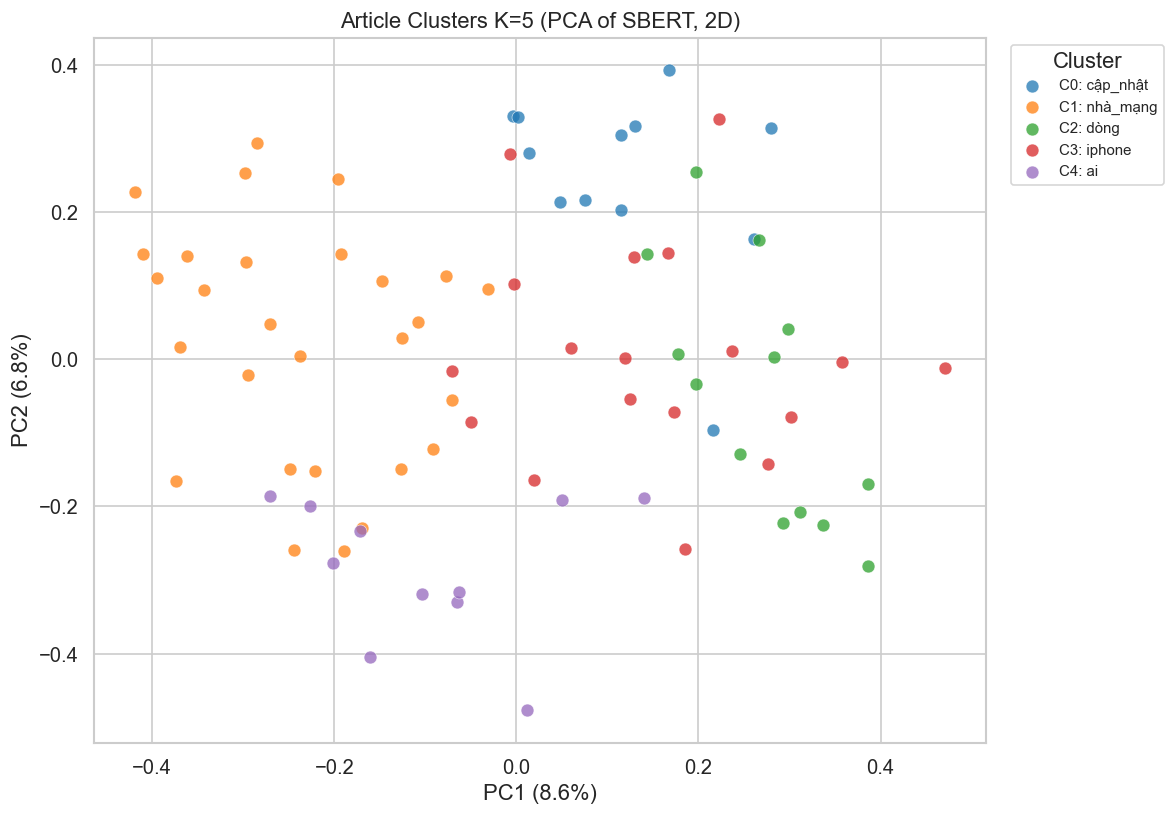

In [182]:
pca_viz = PCA(n_components=2, random_state=42)
coords = pca_viz.fit_transform(tech_embeddings)

palette = sns.color_palette('tab10', N_CLUSTERS)
fig, ax = plt.subplots(figsize=(10, 7))

for c in range(N_CLUSTERS):
    mask = df_tech['cluster'] == c
    short_label = cluster_labels[c].split(' | ')[0][:20]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=f'C{c}: {short_label}', color=palette[c],
               alpha=0.75, s=60, edgecolors='white', linewidths=0.4)

ax.set_title(f'Article Clusters K={N_CLUSTERS} (PCA of SBERT, 2D)')
ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.1%})')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

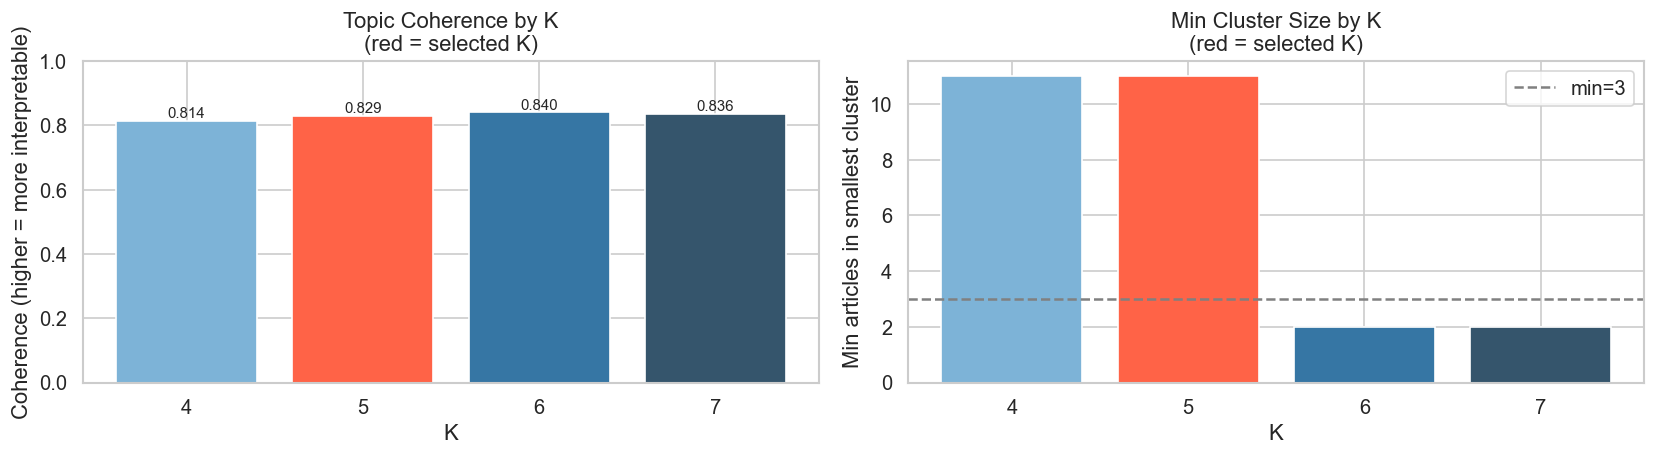

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ks = list(EXPLORE_RANGE)
cohs = [explore_results[k]['coherence'] for k in ks if k in explore_results]
min_sizes = [min(explore_results[k]['sizes'].values()) for k in ks if k in explore_results]
ks_valid = [k for k in ks if k in explore_results]

bar_colors = ['tomato' if k == N_CLUSTERS else sns.color_palette('Blues_d', len(ks_valid))[i]
              for i, k in enumerate(ks_valid)]

axes[0].bar([str(k) for k in ks_valid], cohs, color=bar_colors, edgecolor='white')
axes[0].set_title('Topic Coherence by K\n(red = selected K)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Coherence (higher = more interpretable)')
axes[0].set_ylim(0, 1)
for i, (k, v) in enumerate(zip(ks_valid, cohs)):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar([str(k) for k in ks_valid], min_sizes, color=bar_colors, edgecolor='white')
axes[1].set_title('Min Cluster Size by K\n(red = selected K)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Min articles in smallest cluster')
axes[1].axhline(3, color='gray', linestyle='--', label='min=3')
axes[1].legend()

plt.tight_layout()
plt.show()


In [184]:
tfidf_tech = TfidfVectorizer(
    max_features=300, ngram_range=(1, 2),
    stop_words=list(STOPWORDS), token_pattern=r'(?u)\b\w\w+\b', min_df=2,
)
tfidf_tech_matrix = tfidf_tech.fit_transform(df_tech['tokenized'])
tech_tfidf_scores = dict(zip(
    tfidf_tech.get_feature_names_out(),
    tfidf_tech_matrix.mean(axis=0).A1
))

keyword_embeds = sbert.encode(list(tech_tfidf_scores.keys()), normalize_embeddings=True, show_progress_bar=False)
query_embed_mean = normalize(query_embeddings.mean(axis=0, keepdims=True))
kw_relevance = cosine_similarity(keyword_embeds, query_embed_mean).flatten()

kw_df = pd.DataFrame({
    'keyword': list(tech_tfidf_scores.keys()),
    'tfidf': list(tech_tfidf_scores.values()),
    'semantic': kw_relevance,
})
kw_df['combined'] = kw_df['tfidf'] * kw_df['semantic']
kw_df = kw_df.sort_values('combined', ascending=False).reset_index(drop=True)

print('Top 20 tech-relevant keywords (TF-IDF x semantic):')
print(kw_df.head(20).to_string(index=False))

Top 20 tech-relevant keywords (TF-IDF x semantic):
     keyword    tfidf  semantic  combined
      iphone 0.054517  0.306894  0.016731
    nhà_mạng 0.032092  0.515025  0.016528
    ứng_dụng 0.038862  0.339324  0.013187
        thuê 0.051034  0.224789  0.011472
    màn_hình 0.032590  0.344728  0.011235
       apple 0.052222  0.211210  0.011030
  điện_thoại 0.050217  0.204456  0.010267
    cập_nhật 0.037029  0.248018  0.009184
        dòng 0.036749  0.249000  0.009150
         máy 0.021848  0.402693  0.008798
    thiết_kế 0.041270  0.209440  0.008644
thuê di_động 0.026215  0.312786  0.008200
     kết_nối 0.026337  0.310570  0.008179
         ios 0.016279  0.466167  0.007589
      google 0.028778  0.262097  0.007543
    nền_tảng 0.021188  0.332599  0.007047
          ai 0.052160  0.133991  0.006989
    xác_thực 0.035196  0.191611  0.006744
    máy_tính 0.014549  0.458041  0.006664
     dữ_liệu 0.032919  0.197529  0.006502


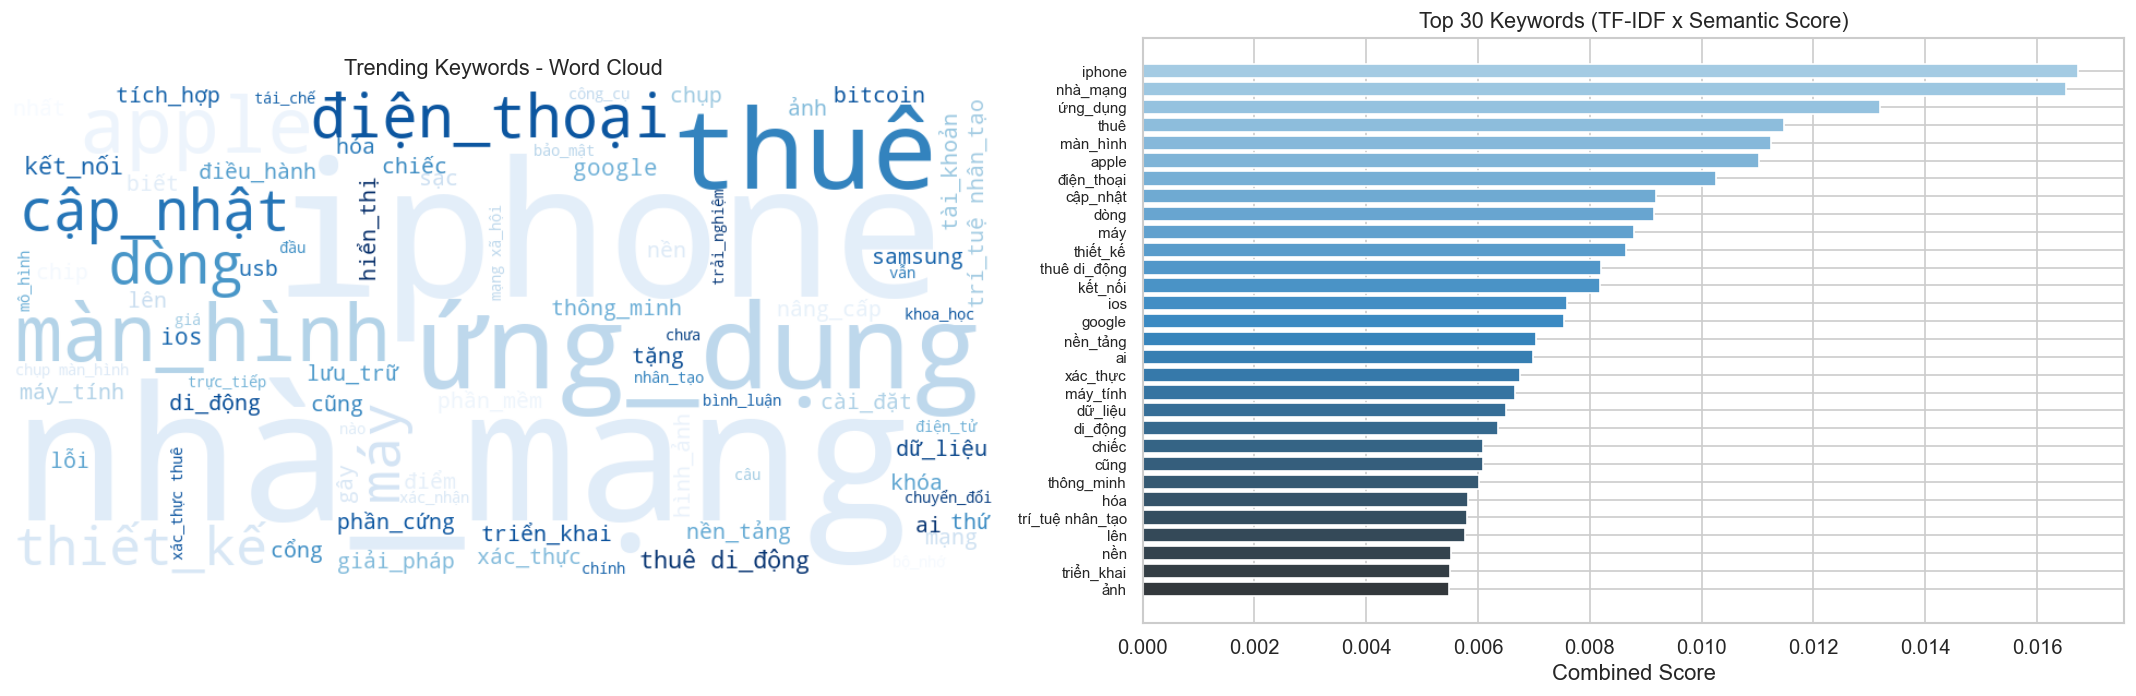

In [185]:
TOP_N = 30
top_kw = kw_df.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc = WordCloud(width=900, height=450, background_color='white', colormap='Blues', max_words=80)
wc.generate_from_frequencies(dict(zip(kw_df['keyword'], kw_df['combined'])))
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Trending Keywords - Word Cloud', fontsize=13)

colors = sns.color_palette('Blues_d', TOP_N)
axes[1].barh(top_kw['keyword'][::-1], top_kw['combined'][::-1], color=colors[::-1])
axes[1].set_title(f'Top {TOP_N} Keywords (TF-IDF x Semantic Score)', fontsize=13)
axes[1].set_xlabel('Combined Score')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

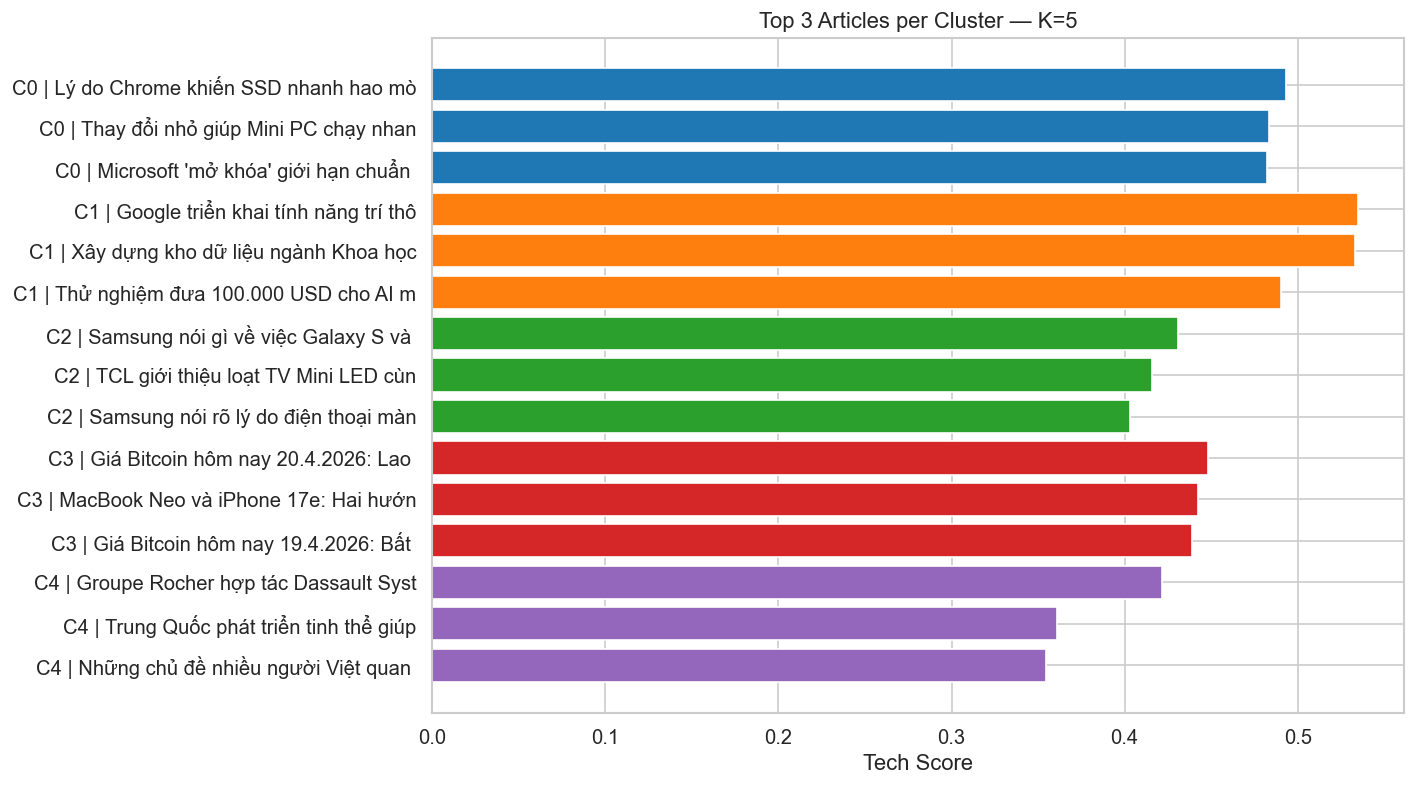

                                        cluster_label                                                                                                                                title       source  tech_score
       cập_nhật | lưu_trữ | máy | dung_lượng | bộ_nhớ                                                                               Lý do Chrome khiến SSD nhanh hao mòn và cách khắc phục    thanhnien    0.493375
       cập_nhật | lưu_trữ | máy | dung_lượng | bộ_nhớ                                                                                Thay đổi nhỏ giúp Mini PC chạy nhanh như máy tính bàn    thanhnien    0.483165
       cập_nhật | lưu_trữ | máy | dung_lượng | bộ_nhớ                                                                        Microsoft 'mở khóa' giới hạn chuẩn FAT32, hỗ trợ lên đến 2 TB    thanhnien    0.482151
nhà_mạng | thuê | xác_thực | xác_thực thuê | ứng_dụng                                                          Google triển khai tính năng trí thông min

In [186]:
highlighted = (
    df_tech
    .sort_values('tech_score', ascending=False)
    .groupby('cluster')
    .head(3)
    .sort_values(['cluster', 'tech_score'], ascending=[True, False])
    [['cluster', 'cluster_label', 'title', 'source', 'published_at', 'tech_score', 'url']]
    .reset_index(drop=True)
)

highlighted['label'] = 'C' + highlighted['cluster'].astype(str) + ' | ' + highlighted['title'].str[:35]

palette = sns.color_palette('tab10', N_CLUSTERS)
colors_bar = [palette[c % 10] for c in highlighted['cluster']]

fig, ax = plt.subplots(figsize=(12, max(4, len(highlighted) * 0.45)))
ax.barh(highlighted['label'], highlighted['tech_score'], color=colors_bar)
ax.set_xlabel('Tech Score')
ax.set_title(f'Top 3 Articles per Cluster — K={N_CLUSTERS}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(highlighted[['cluster_label', 'title', 'source', 'tech_score']].to_string(index=False))

In [187]:
week_start = df_tech['published_at'].min().date().isoformat()
week_end   = df_tech['published_at'].max().date().isoformat()

trending_keywords = top_kw['keyword'].tolist()

highlighted_news = []
for _, row in highlighted.iterrows():
    highlighted_news.append({
        'cluster': int(row['cluster']),
        'cluster_label': row['cluster_label'],
        'title': row['title'],
        'source': row['source'],
        'published_at': row['published_at'].isoformat(),
        'tech_score': round(float(row['tech_score']), 4),
        'url': row['url'],
    })

cluster_summary = []
for c in sorted(cluster_labels):
    subset = df_tech[df_tech['cluster'] == c]
    cluster_summary.append({
        'cluster_id': int(c),
        'label': cluster_labels[c],
        'n_articles': len(subset),
        'top_sources': {str(k): int(v)
                        for k, v in subset['source'].value_counts().head(3).items()},
        'avg_tech_score': round(float(subset['tech_score'].mean()), 4),
    })

report = {
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'week_range': {'start': week_start, 'end': week_end},
    'stats': {
        'total_articles_crawled': len(df_raw),
        'articles_past_7_days': len(df),
        'articles_tech_filtered': len(df_tech),
        'threshold_used': THRESHOLD,
        'n_clusters': int(N_CLUSTERS),
        'coherence': round(float(explore_results[N_CLUSTERS]['coherence']), 4),
    },
    'trending_keywords': trending_keywords,
    'cluster_summary': cluster_summary,
    'highlighted_news': highlighted_news,
}

report_path = OUTPUT_DIR / 'weekly_report.json'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f'Saved: {report_path}')
print(json.dumps(report['stats'], indent=2))

Saved: outputs\weekly_report.json
{
  "total_articles_crawled": 512,
  "articles_past_7_days": 94,
  "articles_tech_filtered": 82,
  "threshold_used": 0.25,
  "n_clusters": 5,
  "coherence": 0.8286
}


In [188]:
def build_markdown(report):
    lines = []
    lines.append('# Weekly Tech News Report')
    lines.append(f"**Period:** {report['week_range']['start']} → {report['week_range']['end']}")
    lines.append(f"**Generated:** {report['generated_at']}")
    lines.append('')
    lines.append('## Executive Summary')
    s = report['stats']
    lines.append(
        f"Trong tuần từ **{report['week_range']['start']}** đến **{report['week_range']['end']}**, "
        f"hệ thống thu thập được **{s['total_articles_crawled']:,}** bài báo, "
        f"trong đó **{s['articles_past_7_days']:,}** bài thuộc 7 ngày gần nhất. "
        f"Sau lọc semantic (threshold={s['threshold_used']}), còn lại **{s['articles_tech_filtered']:,}** bài công nghệ "
        f"được phân thành **{s['n_clusters']}** nhóm chủ đề (coherence={s['coherence']})."
    )
    lines.append('')
    lines.append('Các nhóm chủ đề nổi bật trong tuần:')
    for cs in report['cluster_summary']:
        lines.append(f"- **Cluster {cs['cluster_id']}** – {cs['label']}: {cs['n_articles']} bài")
    lines.append('')
    lines.append('## Trending Keywords')
    lines.append(' · '.join(f'`{k}`' for k in report['trending_keywords'][:20]))
    lines.append('')
    lines.append('## Highlighted News')
    current_cluster = None
    for item in report['highlighted_news']:
        if item['cluster'] != current_cluster:
            current_cluster = item['cluster']
            lines.append(f"### Cluster {item['cluster']}: {item['cluster_label']}")
        date_str = item['published_at'][:10]
        url = item['url']
        title = item['title']
        source = item['source']
        score = item['tech_score']
        if url:
            lines.append(f'- [{title}]({url}) — *{source}* ({date_str}) | score: {score}')
        else:
            lines.append(f'- **{title}** — *{source}* ({date_str}) | score: {score}')
    return '\n'.join(lines)

md_content = build_markdown(report)
md_path = OUTPUT_DIR / 'weekly_report.md'
with open(md_path, 'w', encoding='utf-8') as f:
    f.write(md_content)

print(f'Saved: {md_path}')
print()
print(md_content[:2000])

Saved: outputs\weekly_report.md

# Weekly Tech News Report
**Period:** 2026-04-14 → 2026-04-21
**Generated:** 2026-04-21T01:48:21.190779+00:00

## Executive Summary
Trong tuần từ **2026-04-14** đến **2026-04-21**, hệ thống thu thập được **512** bài báo, trong đó **94** bài thuộc 7 ngày gần nhất. Sau lọc semantic (threshold=0.25), còn lại **82** bài công nghệ được phân thành **5** nhóm chủ đề (coherence=0.8286).

Các nhóm chủ đề nổi bật trong tuần:
- **Cluster 0** – cập_nhật | lưu_trữ | máy | dung_lượng | bộ_nhớ: 12 bài
- **Cluster 1** – nhà_mạng | thuê | xác_thực | xác_thực thuê | ứng_dụng: 28 bài
- **Cluster 2** – dòng | samsung | màn_hình | thiết_kế | s27: 13 bài
- **Cluster 3** – iphone | apple | ios | tái_chế | nâng_cấp: 18 bài
- **Cluster 4** – ai | nhân_tạo | trí_tuệ nhân_tạo | triển_khai | sâu: 11 bài

## Trending Keywords
`iphone` · `nhà_mạng` · `ứng_dụng` · `thuê` · `màn_hình` · `apple` · `điện_thoại` · `cập_nhật` · `dòng` · `máy` · `thiết_kế` · `thuê di_động` · `kết_nối` · `i